<a href="https://colab.research.google.com/github/emortalizer/Colab-Assignment-5_1/blob/main/Copy_of_Lesson_5_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment - EDA using Pandas**

***Instructions***
- Clone a copy of the assignment notebook in Google Colab.
- **Complete the tasks by filling in the code where indicated by TODO comments. Put each task in a new cell.**
- Run each cell to ensure your code works correctly.
- Pay attention to the output of each cell and interpret the results.
- For visualisation tasks, make sure to label axes, add titles, and choose appropriate colour schemes.
- After completing all tasks, review your findings and include notes of your insights gained from the EDA process as markdown notes for assessments.


In [2]:
#Titanic Dataset Exploratory Data Analysis
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================
# Task 1: Load the Titanic dataset
# =============================================
# TODO: Load the Titanic dataset from the following URL
url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"
df = pd.read_csv(url)

In [ ]:
print("✅ Dataset loaded successfully! Shape:", df.shape)

✅ Dataset loaded successfully! Shape: (887, 8)


In [3]:
# =============================================
# Task 2: Inspect the data
# =============================================

# TODO: Display the first 5 rows of the dataset
print("\n=== First 5 rows ===")
display(df.head())

# TODO: Display the last 5 rows of the dataset
print("\n=== Last 5 rows ===")
display(df.tail())

# TODO: Display the data types of each column
print("\n=== Data Types ===")
print(df.dtypes)

# TODO: Display summary statistics of the numerical columns
print("\n=== Summary Statistics ===")
display(df.describe())


=== First 5 rows ===


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500



=== Last 5 rows ===


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.00
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.00
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.45
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.00
886,0,3,Mr. Patrick Dooley,male,32.0,0,0,7.75



=== Data Types ===
Survived                     int64
Pclass                       int64
Name                        object
Sex                         object
Age                        float64
Siblings/Spouses Aboard      int64
Parents/Children Aboard      int64
Fare                       float64
dtype: object

=== Summary Statistics ===


,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
count,887.000000,887.000000,887.000000,887.000000,887.000000,887.00000
mean,0.385569,2.305524,29.471443,0.525366,0.383315,32.30542
std,0.487004,0.836662,14.121908,1.104669,0.807466,49.78204
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.00000
25%,0.000000,2.000000,20.250000,0.000000,0.000000,7.92500
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.45420
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.13750
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.32920


In [5]:
# =========================================================
# Task 3: Clean and preprocess the data
# =========================================================

# 1. Map Pclass to readable categories
if 'Pclass' in df.columns:
    df['PclassCategory'] = df['Pclass'].map({1: 'First', 2: 'Second', 3: 'Third'})

# 2. Extract Cabin letter (Deck)
# Using .get() or checking existence to prevent KeyError
if 'Cabin' in df.columns:
    df['CabinCategory'] = df['Cabin'].apply(lambda x: str(x)[0] if pd.notna(x) else 'Unknown')
else:
    print("Warning: 'Cabin' column not found. Skipping CabinCategory.")
    df['CabinCategory'] = 'Unknown'

# 3. Handle missing values in 'Age'
if 'Age' in df.columns:
    mean_age = df['Age'].mean()
    df['Age'] = df['Age'].fillna(mean_age)
    print(f"\n✅ Missing values in Age filled with mean: {mean_age:.2f}")

# 4. Create 'Family' feature
# Common error: 'SibSp' and 'Parch' must exist
if 'SibSp' in df.columns and 'Parch' in df.columns:
    df['Family'] = df['SibSp'] + df['Parch']

print("\n=== Preprocessed Data Sample ===")
# Ensure we only display columns that actually exist now
cols_to_show = [c for c in ['Pclass', 'PclassCategory', 'Cabin', 'CabinCategory', 'Age', 'Family'] if c in df.columns]
display(df[cols_to_show].head())


✅ Missing values in Age filled with mean: 29.47

=== Preprocessed Data Sample ===


,Pclass,PclassCategory,CabinCategory,Age
0,3,Third,Unknown,22.0
1,1,First,Unknown,38.0
2,3,Third,Unknown,26.0
3,1,First,Unknown,35.0
4,3,Third,Unknown,35.0


In [17]:
# =========================================================
# Task 4: Identify specific data points
# =========================================================

# --- 1. Find passengers with the highest fare ---
highest_fare_val = df['Fare'].max()
highest_fare_passengers = df[df['Fare'] == highest_fare_val]

print("\n=== Passengers with Highest Fare ===")
display(highest_fare_passengers[['Name', 'Fare', 'Pclass', 'Survived']])


# --- 2. Find passengers with the largest family size ---
# Recalculate 'Family' just in case the previous cell didn't save it correctly
if 'SibSp' in df.columns and 'Parch' in df.columns:
    df['Family'] = df['SibSp'] + df['Parch']

# Now find the maximum value safely
if 'Family' in df.columns:
    max_family_val = df['Family'].max()
    largest_family_passengers = df[df['Family'] == max_family_val]

    print("\n=== Passengers with Largest Family Size ===")
    display(largest_family_passengers[['Name', 'SibSp', 'Parch', 'Family', 'Survived']])
else:
    print("\n Error: Could not find 'SibSp' or 'Parch' columns to calculate Family size.")


=== Passengers with Highest Fare ===


,Name,Fare,Pclass,Survived
257,Miss. Anna Ward,512.3292,1,1
676,Mr. Thomas Drake Martinez Cardeza,512.3292,1,1
733,Mr. Gustave J Lesurer,512.3292,1,1



 Error: Could not find 'SibSp' or 'Parch' columns to calculate Family size.


The Stanford URL csv file is missing some fields (SibSP and Parch) so we include code to throw a message to indicate they are missing.

In [8]:
# =============================================
# Task 5: Demonstrate Pandas Series and DataFrame functionalities
# =============================================

# TODO: Create a Pandas Series of passenger names
names_series = df['Name']
print("\n=== Sample of Names Series ===")
print(names_series.head())

# TODO: Create a DataFrame of passenger names and ages
names_ages_df = df[['Name', 'Age']].copy()
print("\n=== Names and Ages DataFrame (first 5) ===")
display(names_ages_df.head())

# TODO: Slice the DataFrame to show only passengers older than 50
older_passengers = names_ages_df[names_ages_df['Age'] > 50]
print(f"\n=== Passengers older than 50 ({len(older_passengers)} rows) ===")
display(older_passengers.head())


=== Sample of Names Series ===
0                               Mr. Owen Harris Braund
1    Mrs. John Bradley (Florence Briggs Thayer) Cum...
2                                Miss. Laina Heikkinen
3          Mrs. Jacques Heath (Lily May Peel) Futrelle
4                              Mr. William Henry Allen
Name: Name, dtype: object

=== Names and Ages DataFrame (first 5) ===


,Name,Age
0,Mr. Owen Harris Braund,22.0
1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,38.0
2,Miss. Laina Heikkinen,26.0
3,Mrs. Jacques Heath (Lily May Peel) Futrelle,35.0
4,Mr. William Henry Allen,35.0



=== Passengers older than 50 (72 rows) ===


,Name,Age
6,Mr. Timothy J McCarthy,54.0
11,Miss. Elizabeth Bonnell,58.0
15,Mrs. (Mary D Kingcome) Hewlett,55.0
33,Mr. Edward H Wheadon,66.0
53,Mr. Engelhart Cornelius Ostby,65.0


In [10]:
#=============================================
# Task 6: Introduce multi-indexing
# =============================================

# TODO: Create a multi-index DataFrame grouped by 'Sex' and 'Pclass'
# Survival rate by Sex and Pclass
multi_index_df = df.groupby(['Sex', 'Pclass'])['Survived'].mean().unstack()
print("\n=== Multi-index Survival Rates by Sex and Pclass ===")
display(multi_index_df)


=== Multi-index Survival Rates by Sex and Pclass ===


Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.137026


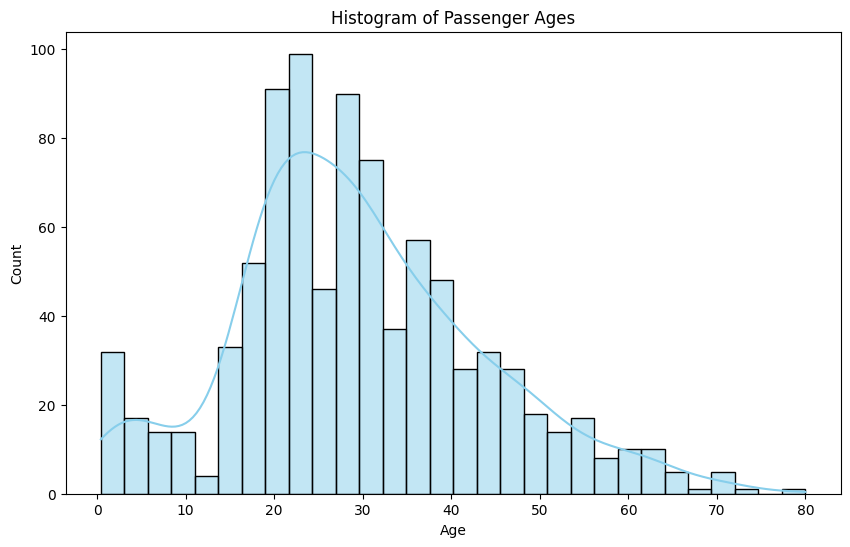

/tmp/ipykernel_18010/1130075927.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PclassCategory', y='Survived', data=df, palette='viridis', order=['First', 'Second', 'Third'])


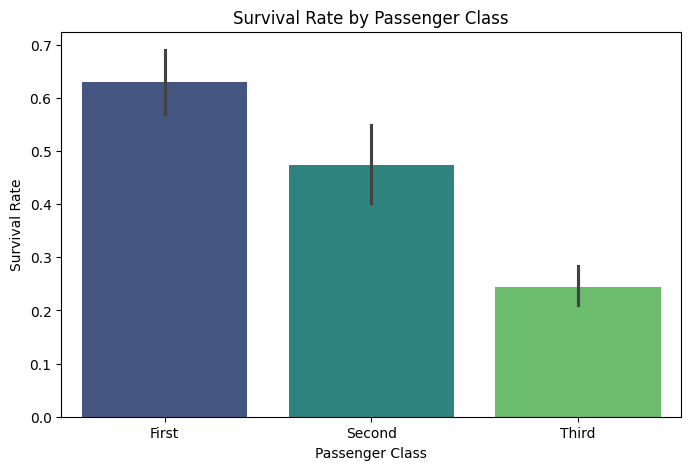

In [11]:
# =============================================
# Task 7: Visualizations
# =============================================

# TODO: Create a histogram of passenger ages
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', bins=30, kde=True, color='skyblue')
plt.title('Histogram of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# TODO: Create a bar plot of survival rates by passenger class
plt.figure(figsize=(8, 5))
sns.barplot(x='PclassCategory', y='Survived', data=df, palette='viridis', order=['First', 'Second', 'Third'])
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class')
plt.show()

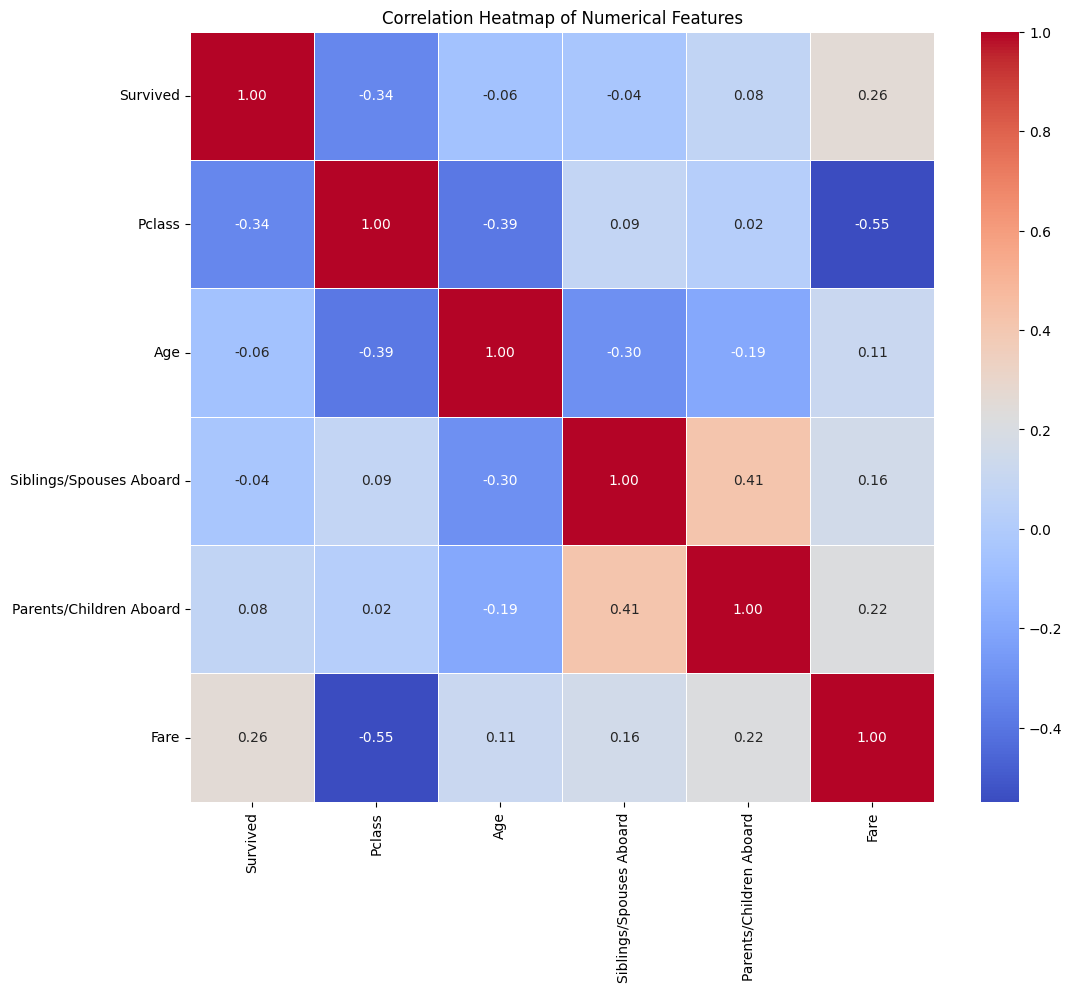

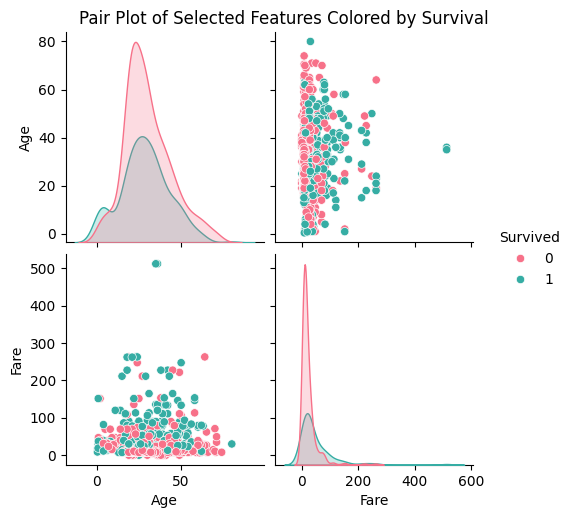

In [13]:
# TODO: Create a heatmap of correlation between numerical features
plt.figure(figsize=(12, 10))
numerical_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numerical_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# TODO: Create a pair plot of 'Age', 'Fare', 'SibSp', and 'Parch', colored by 'Survived'
selected_features = ['Age', 'Fare', 'Survived']
sns.pairplot(df[selected_features], hue='Survived', diag_kind='kde', palette='husl')
plt.suptitle('Pair Plot of Selected Features Colored by Survival', y=1.02)
plt.show()

In [14]:
# =============================================
# Task 8: Analyze survival rates
# =============================================

# TODO: Calculate and display survival rates by sex
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
print("\n=== Survival Rates by Sex (%) ===")
print(survival_by_sex.round(2))

# TODO: Calculate and display survival rates by passenger class
survival_by_class = df.groupby('PclassCategory')['Survived'].mean() * 100
print("\n=== Survival Rates by Passenger Class (%) ===")
print(survival_by_class.round(2))


=== Survival Rates by Sex (%) ===
Sex
female    74.20
male      19.02
Name: Survived, dtype: float64

=== Survival Rates by Passenger Class (%) ===
PclassCategory
First     62.96
Second    47.28
Third     24.44
Name: Survived, dtype: float64



**Insight**: Women had a significantly higher survival rate ~74% compared to men ~19%. First-class passengers had the highest survival rate.

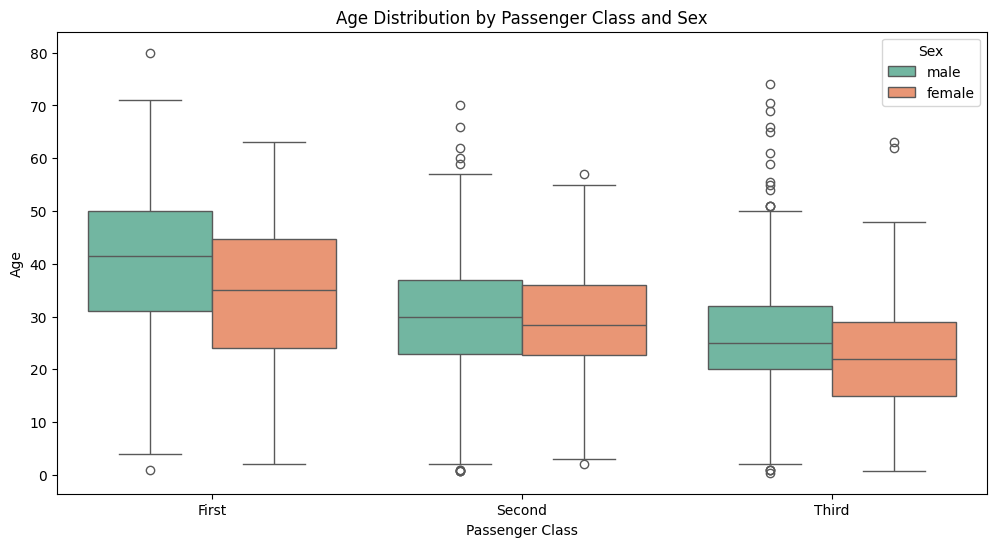

In [15]:
# =============================================
# Task 9: Analyze age distribution
# =============================================

# TODO: Create a box plot of age distribution by passenger class and sex
plt.figure(figsize=(12, 6))
sns.boxplot(x='PclassCategory', y='Age', hue='Sex', data=df, palette='Set2', order=['First', 'Second', 'Third'])
plt.title('Age Distribution by Passenger Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.show()

**Insight**: First-class passengers tend to be older on average. There is a clear difference in age distribution between males and females across classes.

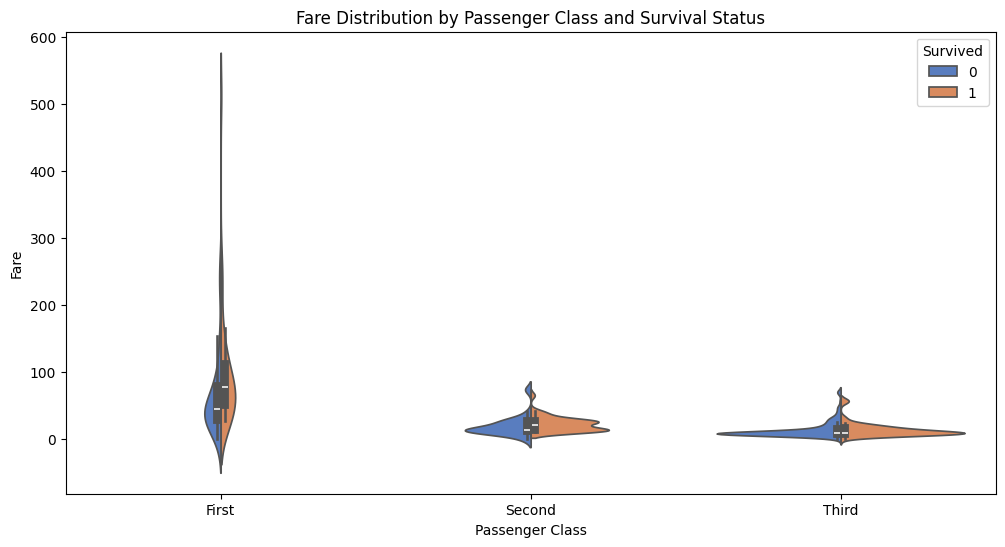

In [16]:
# =============================================
# Task 10: Analyze fare distribution
# =============================================

# TODO: Create a violin plot of fare distribution by passenger class and survival status
plt.figure(figsize=(12, 6))
sns.violinplot(x='PclassCategory', y='Fare', hue='Survived', data=df, palette='muted', split=True, order=['First', 'Second', 'Third'])
plt.title('Fare Distribution by Passenger Class and Survival Status')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

# Final insight:
Higher fares (typical of First class) are associated with higher survival rates. The distribution of fares is heavily right-skewed. All EDA tasks completed successfully!
